Amount of missing values found: 0
Dataset Shape: (27762, 92)


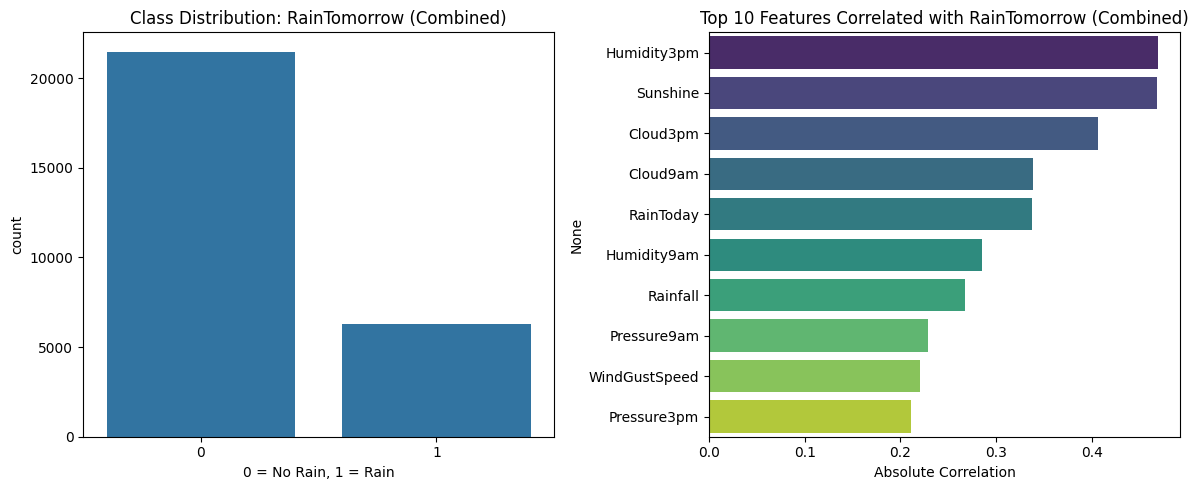

Training data shape: (22209, 91)
Testing data shape: (5553, 91)
--- Majority Class Baseline ---
Accuracy:  0.7790
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000


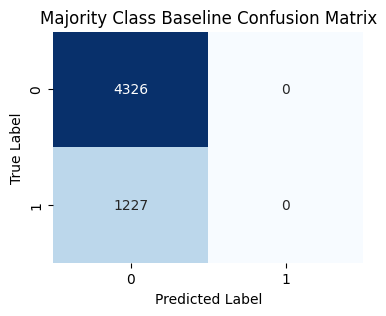



--- Logistic Regression ---
Accuracy:  0.8622
Precision: 0.7432
Recall:    0.5754
F1 Score:  0.6486


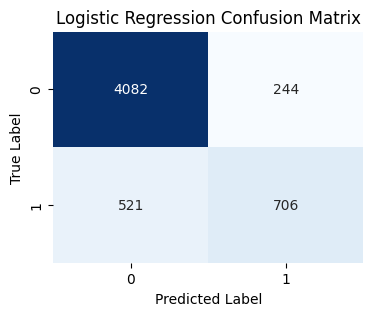



--- Random Forest ---
Accuracy:  0.8667
Precision: 0.7783
Recall:    0.5550
F1 Score:  0.6480


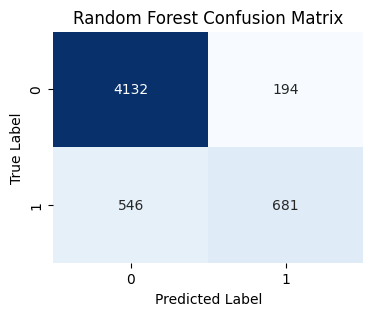

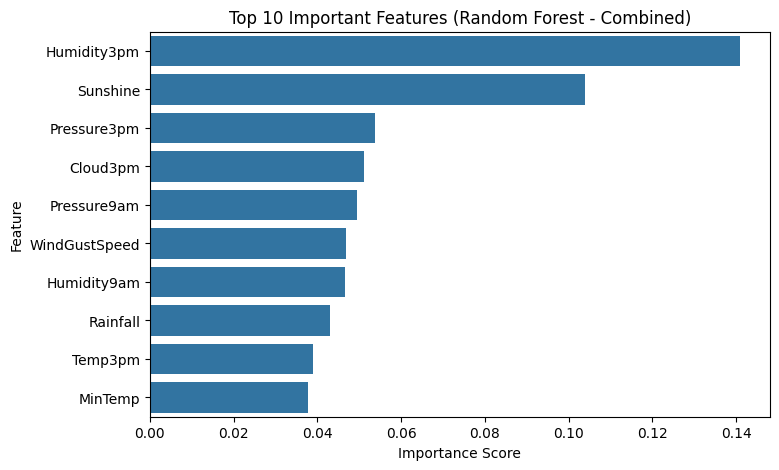

In [1]:
#data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')

#load the combined slice from the group repository
df = pd.read_csv("https://raw.githubusercontent.com/keavenq/ecs171-group2-rain-australia/main/data/combined.csv")

#check how many missing values exist before feeding into models
NANamt = df.isna().sum().sum()
print(f"Amount of missing values found: {NANamt}")
#drop rows that have missing values
df = df.dropna()

# Ensure the target column is an integer (0 or 1)
df['RainTomorrow'] = df['RainTomorrow'].astype(int)

print(f"Dataset Shape: {df.shape}")
df.head()

# EDA
plt.figure(figsize=(12, 5))

# Target Variable Distribution
plt.subplot(1, 2, 1)
sns.countplot(x='RainTomorrow', data=df)
plt.title('Class Distribution: RainTomorrow (Combined)')
plt.xlabel('0 = No Rain, 1 = Rain')

# Top Correlated Features with RainTomorrow
plt.subplot(1, 2, 2)
# look at the top 10 highest correlations
correlations = df.corr()['RainTomorrow'].abs().sort_values(ascending=False)
top_features = correlations.index[1:11] # Skip RainTomorrow itself
sns.barplot(x=correlations[top_features], y=top_features, palette='viridis')
plt.title('Top 10 Features Correlated with RainTomorrow (Combined)')
plt.xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()

# Train/Test Split (Features (X) and Target (y))
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# Split the data (80% train, 20% test) using random_state 42 as per guidelines
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test)

# Train Comparison Model (RandomForest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#predicting on test set
rf_preds = rf_model.predict(X_test)

#output metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print("\n")

#Baseline Predictions
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_test)

evaluate_model(y_test, baseline_preds, "Majority Class Baseline")

# Report results for both models
evaluate_model(y_test, lr_preds, "Logistic Regression")
evaluate_model(y_test, rf_preds, "Random Forest")

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=False).head(10)

# Random Forest Feature Importance
plt.figure(figsize=(8,5))
sns.barplot(x=top_importances.values, y=top_importances.index)
plt.title('Top 10 Important Features (Random Forest - Combined)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()